# Tennis Match Prediction — Surface-Adjusted Elo + XGBoost (ATP + WTA)

Probability model for ATP **and** WTA match outcomes, built to be measured against the
closing bookmaker line (closing-line-value test) and later against Polymarket's uninformed
opening prices.

**v4 changes over v3:**
1. **CLV backtest implemented (§10).** The model's probabilities are now benchmarked directly
   against de-vigged Pinnacle closing prices (the gold-standard market efficiency test).
   Includes an encompassing regression, per-tier log-loss breakdown, and significance-checked
   flat-stake ROI simulation. Betfair Exchange used as a second benchmark when present.
2. **Fatigue features (§6).** Rolling minutes-on-court over 7 and 14 days — the `minutes`
   column was in the CSVs but unused. Fatigue is a real-world signal the close may not fully
   price, especially at Challengers where scheduling data is noisier.
3. **Serve-stat rollup features (§6).** Per-player rolling ace rate, double-fault rate, 1st-serve
   win%, and break-point save rate by surface — computed from existing serve columns. These add
   playing-style information beyond win/loss Elo.
4. **Bug fixes:** qualifying-round date offsets no longer clipped to zero (§3); Elo calibration
   uses the same `MIN_HISTORY` threshold as XGBoost training (§5, was hardcoded to 20);
   apples-to-apples Elo vs XGB comparison throughout.

**Data:** Jeff Sackmann `tennis_atp` + `tennis_wta` (CC BY-NC-SA 4.0, attribution, non-commercial).

## 1. Setup & Tunable Constants

In [16]:
import numpy as np, pandas as pd, urllib.request, os, time
from collections import defaultdict
import xgboost as xgb
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'#0e1117','axes.facecolor':'#0e1117',
    'axes.edgecolor':'#444','axes.labelcolor':'white','text.color':'white',
    'xtick.color':'white','ytick.color':'white','grid.color':'#333','font.size':11})

DATA_DIR = 'tennis_data'; os.makedirs(DATA_DIR, exist_ok=True)
SURFACES = ['Hard','Clay','Grass']
TOURS = ['atp','wta']

# -- DATA RANGE -------------------------------------------------------
START_YEAR   = 2000
END_YEAR     = 2026
BURNIN_UNTIL = '2003-01-01'

# -- MARGIN-OF-VICTORY (optional) -------------------------------------
USE_MARGIN_ELO = False
MARGIN_STRENGTH = 0.5

# -- LEVEL-WEIGHTED ELO (v5.1) -- DISABLED ----------------------------
# Reverted: global K-shrink x idle-decay collapses the rating scale. Off by default.
USE_LEVEL_ELO = False
LEVEL_WEIGHT = {
    'G':1.00,'F':1.00,'M':0.90,'A':0.80,'D':0.70,'C':0.55,'S':0.35,
    'P':0.90,'PM':0.90,'I':0.80,
    '125':0.55,'100':0.50,'80':0.45,'75':0.45,'60':0.40,'50':0.40,
    '50+H':0.40,'40':0.35,'35':0.35,'25':0.30,'15':0.25,
}
LEVEL_WEIGHT_DEFAULT = 0.50
def level_weight(level):
    return LEVEL_WEIGHT.get(str(level).strip().upper(), LEVEL_WEIGHT_DEFAULT) if USE_LEVEL_ELO else 1.0

# -- ELO REPLAY CACHE -------------------------------------------------
USE_ELO_CACHE = False
ELO_CACHE = 'elo_replayed.pkl'

# -- ELO CONSTANTS ----------------------------------------------------
BLEND_SURF    = 0.7      # MAX weight on surface Elo vs overall (see adaptive blend below)
K_BASE        = 250.0
K_OFFSET      = 5
K_EXP         = 0.4
DECAY_PER_DAY = 0.0008
DECAY_GRACE   = 30
DECAY_CAP     = 0.30
FORM_WINDOW   = 10
MIN_HISTORY   = 5

# -- ADAPTIVE SURFACE BLEND (v5.2) ------------------------------------
# Shrink the surface rating toward overall when the player has few matches on that surface, so
# an UNPLAYED surface (rating still = 1500 seed) does not poison the blend. 0 surface matches
# -> pure overall Elo; many -> approaches the full BLEND_SURF weight. (Grass query for clay
# players, Charaeva grass = 1500.0, used to collapse to ~50/50.)
USE_ADAPTIVE_SURF = True
SURF_SHRINK_C     = 20
def surf_weight(n_surface):
    return BLEND_SURF * n_surface / (n_surface + SURF_SHRINK_C) if USE_ADAPTIVE_SURF else BLEND_SURF
def blend_elo(overall_r, surf_r, n_surface):
    w = surf_weight(n_surface)
    return w * surf_r + (1 - w) * overall_r

# -- RELIABILITY FLAG (v5.3, revised) ---------------------------------
# The section-9b ECE analysis showed the model is well-calibrated ACROSS |sos_diff| -- i.e.
# cross-level matchups are fine, so there is NO |sos_diff| flag. The only badly-calibrated
# slice was data-poverty (no ranked-opponent history -> ECE ~0.05). So the flag fires on
# thin data, not schedule mismatch.
RELIABLE_MIN_NM = 10   # below this many matches in pool -> low-confidence prediction

# -- SERVE STAT ROLLUPS ------------------------------------------------
SERVE_WINDOW  = 20

# -- FATIGUE -----------------------------------------------------------
FATIGUE_WINDOWS = [7, 14]

# -- CLV BACKTEST ------------------------------------------------------
CLV_ODDS_FILES = ['2025.xlsx', '2026.xlsx']

print('Setup ready. Tune the Elo block above and re-run section 4 onward to improve calibration.')
print(f'Adaptive surface blend: {"ON" if USE_ADAPTIVE_SURF else "OFF"} (C={SURF_SHRINK_C}) | '
      f'Level-weighted Elo: {"ON" if USE_LEVEL_ELO else "OFF"}. '
      f'Changing either auto-invalidates the Elo cache and forces a fresh replay.')

Setup ready. Tune the Elo block above and re-run section 4 onward to improve calibration.
Adaptive surface blend: ON (C=20) | Level-weighted Elo: OFF. Changing either auto-invalidates the Elo cache and forces a fresh replay.


## 2. Download ATP + WTA Data

On a rerun this is a no-op for files already on disk (it only checks existence). **The
current-year file is partial and live-updating** -- delete it before a rerun to pull fresh
results.

In [17]:
import datetime as _dt
CURRENT_YEAR = _dt.date.today().year

def refresh_current_year():
    removed = 0
    for f in os.listdir(DATA_DIR):
        if str(CURRENT_YEAR) in f and f.endswith('.csv'):
            os.remove(os.path.join(DATA_DIR, f)); removed += 1
    print(f'Refreshed: removed {removed} current-year ({CURRENT_YEAR}) file(s); will re-download.')

# Uncomment to force fresh current-season data before a live-prediction run:
# refresh_current_year()

def download(tour, kind, y):
    fn = {'atp': {'matches': f'atp_matches_{y}.csv', 'lower': f'atp_matches_qual_chall_{y}.csv'},
          'wta': {'matches': f'wta_matches_{y}.csv', 'lower': f'wta_matches_qual_itf_{y}.csv'}}[tour][kind]
    path = f'{DATA_DIR}/{fn}'
    if os.path.exists(path):
        return path
    base = f'https://raw.githubusercontent.com/JeffSackmann/tennis_{tour}/master'
    try:
        urllib.request.urlretrieve(f'{base}/{fn}', path); time.sleep(0.15); return path
    except Exception:
        return None

paths = {}
for tour in TOURS:
    main  = [download(tour,'matches',y) for y in range(START_YEAR,END_YEAR+1)]
    lower = [download(tour,'lower',y)   for y in range(START_YEAR,END_YEAR+1)]
    paths[tour] = [p for p in main+lower if p]
    print(f'{tour}: {len(paths[tour])} files')

atp: 54 files
wta: 53 files


## 3. Load & Clean -- glob-based, with round ordering and score parsing

**v4 fixes:**
- **Qualifying-round date offset:** the estimated `match_date` now uses the raw `round_ord`
  (which is negative for qualifying rounds), so qualifying matches are dated *before* the
  main draw start. Previously `clip(lower=0)` collapsed all qualifying rounds onto the same
  date as R128, breaking the rest-days feature for qualifiers.
- **Minutes and serve stats** are preserved from the source CSVs for use in section 6 feature
  engineering.

In [18]:
import glob, re

def load_tour(tour):
    files = sorted(glob.glob(f'{DATA_DIR}/{tour}_matches_*.csv'))
    frames=[]
    for p in files:
        try: frames.append(pd.read_csv(p, low_memory=False))
        except Exception as e: print(f'skip {p}: {e}')
    d = pd.concat(frames, ignore_index=True); d['tour']=tour
    return d

df = pd.concat([load_tour(t) for t in TOURS], ignore_index=True)
df['tourney_date'] = pd.to_datetime(df['tourney_date'], format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['winner_name','loser_name','surface','tourney_date'])
df = df[df['surface'].isin(SURFACES)]

# Round ordering: qualifying precedes main draw; main draw progresses to the final.
ROUND_ORD = {'Q1':-3,'Q2':-2,'Q3':-1,'Q4':-1,'ER':0,
             'R128':1,'RR':1,'BR':1,'R64':2,'R32':3,'R16':4,'QF':5,'SF':6,'F':7}
df['round_ord'] = df['round'].astype(str).str.upper().str.strip().map(ROUND_ORD).fillna(0).astype(int)
df = df.sort_values(['tourney_date','round_ord','match_num']).reset_index(drop=True)

# FIX (v4): estimated match date uses raw round_ord, NOT clipped to 0.
# Qualifying rounds get negative offsets (placed before main-draw start), so rest-days
# between a qualifier and an R64 match is correctly positive instead of zero.
df['match_date'] = df['tourney_date'] + pd.to_timedelta(df['round_ord'] * 1.3, unit='D')

# Parse score -> (winner games, loser games, clean?) ; clean=False for WO/RET/DEF
def parse_score(score):
    if not isinstance(score, str): return (0,0,False)
    s = score.strip()
    if any(t in s.upper() for t in ['W/O','WALKOVER','DEF','ABD','ABN','UNFINISHED']):
        return (0,0,False)
    had_ret = ('RET' in s.upper()) or ('RTD' in s.upper())
    s = re.sub(r'(RET|RTD)','',s,flags=re.IGNORECASE).strip()
    wg=lg=sets=0
    for st in s.split():
        m=re.match(r'(\d+)-(\d+)',st)
        if not m: continue
        wg+=int(m.group(1)); lg+=int(m.group(2)); sets+=1
    if sets==0 or (wg==0 and lg==0): return (0,0,False)
    return (wg,lg, not had_ret)

ps = df['score'].apply(parse_score)
df['w_games']=ps.apply(lambda x:x[0]); df['l_games']=ps.apply(lambda x:x[1]); df['score_clean']=ps.apply(lambda x:x[2])
tot = (df['w_games']+df['l_games']).replace(0,np.nan)
df['dominance_w'] = (df['w_games']/tot).fillna(0.5)

# NEW (v4): ensure minutes & serve-stat columns are present (NaN if missing)
for col in ['minutes','w_ace','w_df','w_svpt','w_1stIn','w_1stWon','w_2ndWon',
            'w_SvGms','w_bpSaved','w_bpFaced',
            'l_ace','l_df','l_svpt','l_1stIn','l_1stWon','l_2ndWon',
            'l_SvGms','l_bpSaved','l_bpFaced']:
    if col not in df.columns:
        df[col] = np.nan

print(f'{len(df):,} matches  {df.match_date.min().date()} -> {df.match_date.max().date()}')
print(f'clean (non WO/RET) scores: {df["score_clean"].mean()*100:.1f}%')
print(f'minutes available: {df["minutes"].notna().mean()*100:.1f}%   serve stats: {df["w_ace"].notna().mean()*100:.1f}%')
for t in TOURS:
    sub=df[df.tour==t]
    print(f'  {t}: {len(sub):,} matches')
unmapped = set(df['round'].astype(str).str.upper().str.strip().unique()) - set(ROUND_ORD)
if unmapped: print('  note: rounds defaulting to ord 0:', unmapped)

801,518 matches  1999-12-30 -> 2026-06-23
clean (non WO/RET) scores: 96.5%
minutes available: 32.1%   serve stats: 36.5%
  atp: 262,725 matches
  wta: 538,793 matches
  note: rounds defaulting to ord 0: {'FINAL', 'NAN'}


## 4. Surface-Adjusted Elo -- Separate Pools per Tour

Players keyed by `(tour, name)` so ATP/WTA never mix. Uses `match_date` (round-adjusted) for
layoff decay. Optionally scales each update by game-dominance (`USE_MARGIN_ELO`).

**v5.1 level-weighting: tried and REVERTED (`USE_LEVEL_ELO = False`).** Scaling K by tournament
level globally shrank rating movement and, via the idle-decay interaction, collapsed the whole
rating scale toward 1500 (every prediction → ~50/50). It also failed to fix the ITF-grinder
inversion. Opponent/level quality still needs addressing, but with a method that doesn't distort
the scale (e.g. excluding the lowest ITF tiers, or rank-seeding) — not a global K shrink.

**v4 change:** the replay also carries `minutes` and serve stats from the source data so
section 6 can compute serve features without a second pass over `df`.

Note: the level weights are folded into the cache key, so toggling `USE_LEVEL_ELO` or editing
`LEVEL_WEIGHT` automatically invalidates `elo_replayed.pkl` and triggers a fresh replay.

In [19]:
def K(n): return K_BASE/(n+K_OFFSET)**K_EXP
def expected(ra, rb): return 1.0/(1.0+10**((rb-ra)/400.0))

import json, hashlib
_elo_key = json.dumps({'S':START_YEAR,'E':END_YEAR,'BS':BLEND_SURF,'KB':K_BASE,'KO':K_OFFSET,
    'KE':K_EXP,'DPD':DECAY_PER_DAY,'DG':DECAY_GRACE,'DC':DECAY_CAP,
    'MARGIN':USE_MARGIN_ELO,'MS':MARGIN_STRENGTH,'N':len(df),
    'LVL':USE_LEVEL_ELO,'LW':LEVEL_WEIGHT,'LWD':LEVEL_WEIGHT_DEFAULT,
    'AS':USE_ADAPTIVE_SURF,'SC':SURF_SHRINK_C}, sort_keys=True)
_elo_hash = hashlib.md5(_elo_key.encode()).hexdigest()[:10]

overall = defaultdict(lambda: 1500.0)
surf = {s: defaultdict(lambda: 1500.0) for s in SURFACES}
last_played={}; n_all=defaultdict(int); n_surf={s: defaultdict(int) for s in SURFACES}

def decay(key, today):
    if key in last_played:
        idle=(today-last_played[key]).days
        if idle>DECAY_GRACE:
            f=min(DECAY_CAP, DECAY_PER_DAY*(idle-DECAY_GRACE))
            overall[key]=1500+(overall[key]-1500)*(1-f)
            for s in SURFACES: surf[s][key]=1500+(surf[s][key]-1500)*(1-f)

_cache_ok = False
if USE_ELO_CACHE and os.path.exists(ELO_CACHE):
    try:
        import pickle as _pk
        with open(ELO_CACHE,'rb') as _f: cached=_pk.load(_f)
        if cached.attrs.get('elo_hash') == _elo_hash:
            elo = cached; _cache_ok = True
            print(f'Loaded cached Elo replay ({len(elo):,} rows, hash {_elo_hash}).')
            print('  NOTE: cache load leaves overall/surf/n_all/n_surf EMPTY -> the predictor '
                  'cannot run.\n  For prediction, set USE_ELO_CACHE=False and re-run this cell.')
    except Exception as e:
        print(f'cache read failed ({e}); replaying.')

if not _cache_ok:
    rows=[]
    for r in df.itertuples():
        s,d,tour=r.surface,r.match_date,r.tour
        w,l=(tour,r.winner_name),(tour,r.loser_name)
        decay(w,d); decay(l,d)
        # v5.2: adaptive surface blend (shrinks to overall when surface history is thin)
        rw=blend_elo(overall[w], surf[s][w], n_surf[s][w])
        rl=blend_elo(overall[l], surf[s][l], n_surf[s][l])
        p_w=expected(rw,rl)
        rows.append({'date':d,'tour':tour,'level':r.tourney_level,'surface':s,
            'winner':r.winner_name,'loser':r.loser_name,'elo_w':rw,'elo_l':rl,'p_w_elo':p_w,
            'ov_w':overall[w],'ov_l':overall[l],'nm_w':n_all[w],'nm_l':n_all[l],
            'rank_w':getattr(r,'winner_rank',np.nan),'rank_l':getattr(r,'loser_rank',np.nan),
            'dominance_w':r.dominance_w,'score_clean':r.score_clean,
            'minutes':getattr(r,'minutes',np.nan),
            'w_ace':getattr(r,'w_ace',np.nan),'w_df':getattr(r,'w_df',np.nan),
            'w_svpt':getattr(r,'w_svpt',np.nan),'w_1stIn':getattr(r,'w_1stIn',np.nan),
            'w_1stWon':getattr(r,'w_1stWon',np.nan),'w_2ndWon':getattr(r,'w_2ndWon',np.nan),
            'w_bpSaved':getattr(r,'w_bpSaved',np.nan),'w_bpFaced':getattr(r,'w_bpFaced',np.nan),
            'l_ace':getattr(r,'l_ace',np.nan),'l_df':getattr(r,'l_df',np.nan),
            'l_svpt':getattr(r,'l_svpt',np.nan),'l_1stIn':getattr(r,'l_1stIn',np.nan),
            'l_1stWon':getattr(r,'l_1stWon',np.nan),'l_2ndWon':getattr(r,'l_2ndWon',np.nan),
            'l_bpSaved':getattr(r,'l_bpSaved',np.nan),'l_bpFaced':getattr(r,'l_bpFaced',np.nan)})
        mult=1.0
        if USE_MARGIN_ELO and r.score_clean:
            mult = 1.0 + MARGIN_STRENGTH*(2*r.dominance_w - 1)
        lw = level_weight(r.tourney_level)
        kw,kl=K(n_all[w])*mult*lw,K(n_all[l])*mult*lw
        ksw,ksl=K(n_surf[s][w])*mult*lw,K(n_surf[s][l])*mult*lw; dl=(1-p_w)
        overall[w]+=kw*dl; overall[l]-=kl*dl; surf[s][w]+=ksw*dl; surf[s][l]-=ksl*dl
        n_all[w]+=1; n_all[l]+=1; n_surf[s][w]+=1; n_surf[s][l]+=1
        last_played[w]=d; last_played[l]=d
    elo=pd.DataFrame(rows); elo.attrs['elo_hash']=_elo_hash
    if USE_ELO_CACHE:
        try:
            import pickle as _pk
            with open(ELO_CACHE,'wb') as _f: _pk.dump(elo,_f)
            print(f'Cached replay (hash {_elo_hash}).')
        except Exception as e: print(f'cache write failed: {e}')
    print(f'Replayed {len(elo):,} matches.')

for t in TOURS:
    top=sorted(((k,v) for k,v in overall.items() if k[0]==t), key=lambda x:-x[1])[:3] if not _cache_ok else []
    if top: print(f'  {t} top-3:', ', '.join(f'{k[1]} {v:.0f}' for k,v in top))

Replayed 801,518 matches.
  atp top-3: Jannik Sinner 2588, Carlos Alcaraz 2582, Novak Djokovic 2422
  wta top-3: Aryna Sabalenka 2591, Iga Swiatek 2580, Elena Rybakina 2518


## 5. Elo Calibration (post burn-in, both tours)

**v4 fix:** uses `MIN_HISTORY` (set in section 1) instead of a hardcoded 20. This ensures the Elo
baseline and the XGBoost model are evaluated on the exact same match pool, making the
comparison apples-to-apples.

Elo on 661,064 mature (>=5) post-burn-in matches:
  accuracy: 0.6711  log_loss: 0.6010  brier: 0.2075
  atp: log_loss=0.6258 n=221,343
  wta: log_loss=0.5885 n=439,721


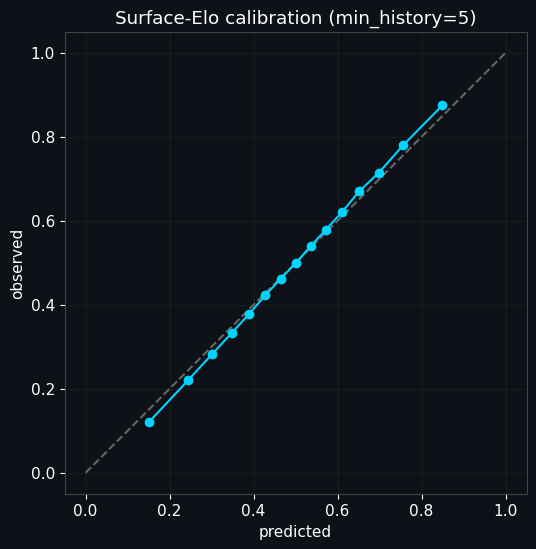

In [20]:
# FIX (v4): use MIN_HISTORY consistently, not a hardcoded 20
ev = elo[(elo['nm_w']>=MIN_HISTORY)&(elo['nm_l']>=MIN_HISTORY)&(elo['date']>=BURNIN_UNTIL)]
rng=np.random.default_rng(0); flip=rng.random(len(ev))<0.5
p1=np.where(flip,1-ev['p_w_elo'],ev['p_w_elo']); y1=np.where(flip,0,1)
print(f'Elo on {len(ev):,} mature (>={MIN_HISTORY}) post-burn-in matches:')
print(f'  accuracy: {(ev["p_w_elo"]>0.5).mean():.4f}  log_loss: {log_loss(y1,np.clip(p1,1e-6,1-1e-6)):.4f}  brier: {brier_score_loss(y1,p1):.4f}')
for t in TOURS:
    m=ev['tour']==t
    print(f'  {t}: log_loss={log_loss(y1[m.values],np.clip(p1[m.values],1e-6,1-1e-6)):.4f} n={m.sum():,}')
frac,mp=calibration_curve(y1,p1,n_bins=15,strategy='quantile')
plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'--',color='#666')
plt.plot(mp,frac,'o-',color='#00d4ff'); plt.title(f'Surface-Elo calibration (min_history={MIN_HISTORY})')
plt.xlabel('predicted'); plt.ylabel('observed'); plt.gca().set_aspect('equal'); plt.grid(alpha=.3); plt.show()

## 6. Feature Engineering (form, H2H, rest, rank + serve/return rollups)

For each match, every feature is the players' state *entering* the match. The serve/return
rollups (**v5**) are trailing per-player averages over the last `SERVE_WINDOW` matches,
recorded *before* the current match is folded into the history — so there is no leakage and
the construction is identical at inference time:

- **`spw`** — serve points won %  (`(1stWon + 2ndWon) / svpt`)
- **`rpw`** — return points won %  (from the opponent's serve line)
- **`ace`** — ace rate per serve point
- **`bps`** — break points saved %

They are NaN until a player has at least one prior match with serve stats; XGBoost handles
that natively. Fill is sparse in the historical Sackmann mix (~36% of rows carry serve stats)
but ~98%+ at ATP/Challenger from the tennis-my-life feed, which is the regime that matters for
live use.

In [21]:
from collections import deque

# v5: serve/return rolling features, done leak-free.
# For each match we record each player's PRE-match trailing averages (from prior matches
# only), THEN update their history with this match. Identical construction at train and
# inference time -> no train/inference distribution mismatch (the bug that killed v4b).
SERVE_COLS = ['w_svpt','w_1stWon','w_2ndWon','w_ace','w_bpSaved','w_bpFaced',
              'l_svpt','l_1stWon','l_2ndWon','l_ace','l_bpSaved','l_bpFaced']
HAS_SERVE = all(c in elo.columns for c in SERVE_COLS)
if not HAS_SERVE:
    print('  WARNING: serve columns absent from the replay (stale Elo cache). Serve features '
          'will be all-NaN.\n  Fix: set USE_ELO_CACHE=False, re-run section 4 once, then re-run this cell.')
else:
    # serve cols can arrive as object dtype (blank/string cells) -> force numeric so the
    # np.isnan guards below work and arithmetic is float.
    elo[SERVE_COLS] = elo[SERVE_COLS].apply(pd.to_numeric, errors='coerce')

form = defaultdict(list)
h2h = defaultdict(lambda: [0, 0])
last_date = {}
# trailing per-player serve/return samples (most recent SERVE_WINDOW matches)
spw_hist = defaultdict(lambda: deque(maxlen=SERVE_WINDOW))   # serve points won %
rpw_hist = defaultdict(lambda: deque(maxlen=SERVE_WINDOW))   # return points won %
ace_hist = defaultdict(lambda: deque(maxlen=SERVE_WINDOW))   # ace rate (per serve point)
bps_hist = defaultdict(lambda: deque(maxlen=SERVE_WINDOW))   # break points saved %
SOS_WINDOW = 20
sos_hist = defaultdict(lambda: deque(maxlen=SOS_WINDOW))     # opponent ranks faced (strength of schedule)

def _avg(dq):
    return float(np.mean(dq)) if len(dq) else np.nan

fr = []
for r in elo.itertuples():
    tour = r.tour; w, l = (tour, r.winner), (tour, r.loser); d = r.date; s = r.surface

    fw = np.mean(form[w][-FORM_WINDOW:]) if form[w] else 0.5
    fl = np.mean(form[l][-FORM_WINDOW:]) if form[l] else 0.5
    hw, hl = h2h[(w, l)]
    rw = (d - last_date[w]).days if w in last_date else 30
    rl = (d - last_date[l]).days if l in last_date else 30

    row = {'date':d, 'tour':tour, 'level':r.level, 'surface':s,
        'winner':r.winner, 'loser':r.loser,
        'elo_diff_w': r.elo_w - r.elo_l, 'ov_diff_w': r.ov_w - r.ov_l, 'p_elo_w': r.p_w_elo,
        'form_w':fw, 'form_l':fl, 'h2h_w':hw - hl,
        'rest_w':min(rw, 60), 'rest_l':min(rl, 60),
        'rank_diff_w': (r.rank_l - r.rank_w) if not (np.isnan(r.rank_w) or np.isnan(r.rank_l)) else 0,
        'nm_w':r.nm_w, 'nm_l':r.nm_l, 'min_nm':min(r.nm_w, r.nm_l),
        # pre-match serve/return form (NaN until the player has serve history)
        'spw_w':_avg(spw_hist[w]), 'spw_l':_avg(spw_hist[l]),
        'rpw_w':_avg(rpw_hist[w]), 'rpw_l':_avg(rpw_hist[l]),
        'ace_w':_avg(ace_hist[w]), 'ace_l':_avg(ace_hist[l]),
        'bps_w':_avg(bps_hist[w]), 'bps_l':_avg(bps_hist[l]),
        'sos_w':_avg(sos_hist[w]), 'sos_l':_avg(sos_hist[l])}

    fr.append(row)

    form[w].append(1); form[l].append(0)
    h2h[(w, l)][0] += 1; h2h[(l, w)][1] += 1
    last_date[w] = d; last_date[l] = d

    # update serve/return history from THIS match (after recording -> no leakage)
    if HAS_SERVE:
        wsv, lsv = r.w_svpt, r.l_svpt
        if wsv and lsv and not (np.isnan(wsv) or np.isnan(lsv)) and wsv > 0 and lsv > 0:
            spw_hist[w].append((r.w_1stWon + r.w_2ndWon) / wsv)        # winner serving
            spw_hist[l].append((r.l_1stWon + r.l_2ndWon) / lsv)        # loser serving
            rpw_hist[w].append((lsv - r.l_1stWon - r.l_2ndWon) / lsv)  # winner returning
            rpw_hist[l].append((wsv - r.w_1stWon - r.w_2ndWon) / wsv)  # loser returning
            ace_hist[w].append(r.w_ace / wsv); ace_hist[l].append(r.l_ace / lsv)
            if r.w_bpFaced and not np.isnan(r.w_bpFaced) and r.w_bpFaced > 0:
                bps_hist[w].append(r.w_bpSaved / r.w_bpFaced)
            if r.l_bpFaced and not np.isnan(r.l_bpFaced) and r.l_bpFaced > 0:
                bps_hist[l].append(r.l_bpSaved / r.l_bpFaced)

    # v5.3 strength of schedule: record the opponent's RANK faced this match (~80% filled).
    # Robust to inactive-star rank collapse because it uses OPPONENT rank, not own rank.
    if pd.notna(r.rank_l) and float(r.rank_l) > 0: sos_hist[w].append(float(r.rank_l))
    if pd.notna(r.rank_w) and float(r.rank_w) > 0: sos_hist[l].append(float(r.rank_w))

F = pd.DataFrame(fr)

# Randomize perspective (p1/p2) to remove winner bias
rng = np.random.default_rng(42); flip = rng.random(len(F)) < 0.5

data = F[['date','tour','surface','level','min_nm','winner','loser']].copy()
data['flip'] = flip
data['elo_diff']   = np.where(flip, -F['elo_diff_w'], F['elo_diff_w'])
data['ov_diff']    = np.where(flip, -F['ov_diff_w'], F['ov_diff_w'])
data['p_elo']      = np.where(flip, 1 - F['p_elo_w'], F['p_elo_w'])
data['form_p1']    = np.where(flip, F['form_l'], F['form_w'])
data['form_p2']    = np.where(flip, F['form_w'], F['form_l'])
data['h2h']        = np.where(flip, -F['h2h_w'], F['h2h_w'])
data['rest_p1']    = np.where(flip, F['rest_l'], F['rest_w'])
data['rest_p2']    = np.where(flip, F['rest_w'], F['rest_l'])
data['rank_diff']  = np.where(flip, -F['rank_diff_w'], F['rank_diff_w'])

# serve/return diffs (p1 - p2); NaN propagates when either player lacks serve history
data['spw_diff'] = np.where(flip, F['spw_l'] - F['spw_w'], F['spw_w'] - F['spw_l'])
data['rpw_diff'] = np.where(flip, F['rpw_l'] - F['rpw_w'], F['rpw_w'] - F['rpw_l'])
data['ace_diff'] = np.where(flip, F['ace_l'] - F['ace_w'], F['ace_w'] - F['ace_l'])
data['bps_diff'] = np.where(flip, F['bps_l'] - F['bps_w'], F['bps_w'] - F['bps_l'])
# v5.3 opponent-quality: recent avg opponent rank (lower = tougher schedule)
data['sos_diff'] = np.where(flip, F['sos_l'] - F['sos_w'], F['sos_w'] - F['sos_l'])

data['surface_clay']  = (F['surface'] == 'Clay').astype(int)
data['surface_grass'] = (F['surface'] == 'Grass').astype(int)
data['tour_wta']      = (F['tour'] == 'wta').astype(int)
data['y'] = np.where(flip, 0, 1)

_cov = data['spw_diff'].notna().mean() * 100
print('Feature matrix:', data.shape)
print(f'serve/return features populated on {_cov:.1f}% of rows '
      f'(both players have >=1 prior match with serve stats)')
print(f'strength-of-schedule (opp rank) populated on {data["sos_diff"].notna().mean()*100:.1f}% of rows')

Feature matrix: (801518, 26)
serve/return features populated on 51.2% of rows (both players have >=1 prior match with serve stats)
strength-of-schedule (opp rank) populated on 94.7% of rows


## 7. Train XGBoost (post burn-in, time-split, no leakage)

**v5:** serve/return rolling diffs are back in `FEATS` — and this time leak-free. The v4b
problem was that the serve columns held the *current* match's box score (post-match, and
always 0.0 at inference). §6 now feeds each player only their **trailing average over prior
matches**, so the feature is built the same way during training and at prediction time. Where
a player has no serve history the value is NaN, which XGBoost routes natively — no 0.0-vs-NaN
distribution mismatch.

Four diffs added: `spw_diff` (serve points won %), `rpw_diff` (return points won %),
`ace_diff` (ace rate), `bps_diff` (break points saved %) — 17 features total. spw/rpw are the
serve and return halves that a serve/return-split Elo would model explicitly; this is the
lighter-weight version of that idea.

In [22]:
FEATS = [
    'elo_diff', 'ov_diff', 'p_elo',
    'form_p1', 'form_p2', 'h2h',
    'rest_p1', 'rest_p2',
    'rank_diff', 'min_nm',
    'surface_clay', 'surface_grass', 'tour_wta',
    # v5: serve/return rolling diffs, re-added leak-free (trailing pre-match averages).
    # NaN where a player has no prior serve data; XGBoost routes NaN natively, and the
    # value is built identically at train and inference time (no v4b 0.0-vs-NaN mismatch).
    'spw_diff', 'rpw_diff', 'ace_diff', 'bps_diff',
    # v5.3 opponent quality: recent avg opponent RANK (strength of schedule). Lets XGB
    # discount an ITF-inflated Elo when the schedule was weak (Gibson opp-rank ~270 vs
    # Pliskova ~85). Uses opponent rank, so immune to the inactive-star own-rank collapse.
    'sos_diff',
]

d2 = data[(data['min_nm'] >= MIN_HISTORY) & (data['date'] >= BURNIN_UNTIL)].sort_values('date').reset_index(drop=True)
cut = d2['date'].quantile(0.8); tr, te = d2[d2['date'] < cut], d2[d2['date'] >= cut]
print(f'train={len(tr):,}  test={len(te):,}  cut={cut.date()}')
print(f'features: {len(FEATS)}')

model = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=20, reg_lambda=1.0, eval_metric='logloss')
model.fit(tr[FEATS], tr['y'], eval_set=[(te[FEATS], te['y'])], verbose=False)
pred = model.predict_proba(te[FEATS])[:, 1]

print(f'\nTest log_loss: XGB={log_loss(te["y"], pred):.4f}  raw-Elo={log_loss(te["y"], te["p_elo"]):.4f}')
print(f'Test brier:    XGB={brier_score_loss(te["y"], pred):.4f}  raw-Elo={brier_score_loss(te["y"], te["p_elo"]):.4f}')
print(f'Test accuracy: {((pred > 0.5) == te["y"]).mean():.4f}  | XGB beats Elo: {log_loss(te["y"], pred) < log_loss(te["y"], te["p_elo"])}')
for t in TOURS:
    m = (te['tour'] == t).values
    print(f'  {t}: XGB log_loss={log_loss(te["y"][m], pred[m]):.4f}  n={m.sum():,}')

train=528,789  test=132,275  cut=2023-01-28
features: 18

Test log_loss: XGB=0.5825  raw-Elo=0.5979
Test brier:    XGB=0.2002  raw-Elo=0.2063
Test accuracy: 0.6841  | XGB beats Elo: True
  atp: XGB log_loss=0.6304  n=43,189
  wta: XGB log_loss=0.5594  n=89,086


## 8. Feature Importance & Calibration

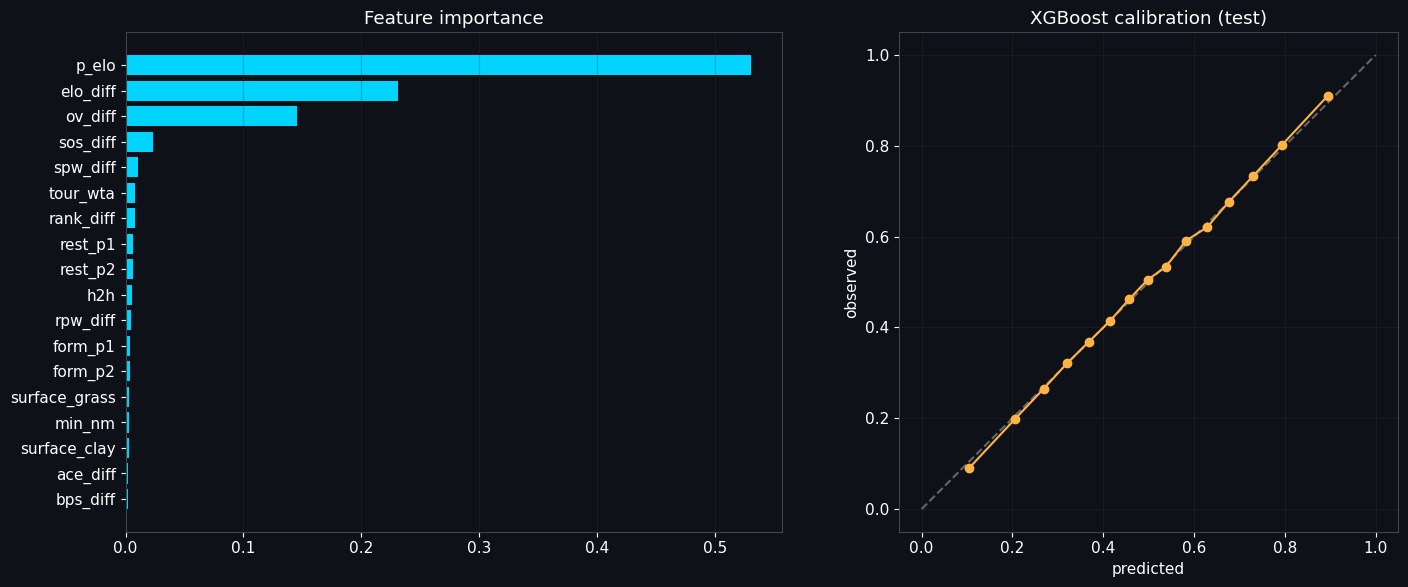

In [23]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
imp = pd.Series(model.feature_importances_, index=FEATS).sort_values()
a1.barh(imp.index, imp.values, color='#00d4ff')
a1.set_title('Feature importance'); a1.grid(alpha=.3, axis='x')

frac, mp = calibration_curve(te['y'], pred, n_bins=15, strategy='quantile')
a2.plot([0, 1], [0, 1], '--', color='#666'); a2.plot(mp, frac, 'o-', color='#ffb347')
a2.set_title('XGBoost calibration (test)'); a2.set_xlabel('predicted'); a2.set_ylabel('observed')
a2.set_aspect('equal'); a2.grid(alpha=.3); plt.tight_layout(); plt.show()

## 9. Performance by Tour x Tier (where is the edge likely to live?)

Segment test accuracy/log-loss by tour and tournament level. The hypothesis: minor events
(ATP Challengers 'C', WTA ITF 'W'/lower) are softly priced. The model being *absolutely*
weakest there is expected; what matters for edge is whether it is strong *relative to the
soft line* -- which the CLV test (section 10) decides.

In [24]:
te_l = te.copy(); te_l['pred'] = pred; te_l['correct'] = (pred > 0.5) == te_l['y']
g = te_l.groupby(['tour', 'level']).agg(
    n=('y', 'size'), acc=('correct', 'mean'),
    logloss=('y', lambda s: log_loss(s, te_l.loc[s.index, 'pred'], labels=[0, 1]) if s.nunique() > 1 else np.nan))
print(g[g['n'] >= 100].sort_values(['tour', 'n'], ascending=[True, False]).to_string())

                n       acc   logloss
tour level                           
atp  C      28939  0.636926  0.637172
     A       6917  0.646812  0.626123
     M       3545  0.635543  0.628588
     G       3065  0.675367  0.587402
     D        584  0.645548  0.599852
wta  15     31002  0.717696  0.546886
     35     13289  0.716909  0.541850
     25      8565  0.715353  0.548901
     75      5069  0.694417  0.569292
     50      4934  0.713620  0.545986
     C       4794  0.684397  0.581462
     60      3470  0.697695  0.568818
     I       3444  0.664344  0.599375
     100     3073  0.692158  0.573183
     G       2737  0.677384  0.592647
     PM      2612  0.652757  0.616775
     P       2412  0.660448  0.615266
     40      2123  0.714084  0.550300
     A        587  0.655877  0.633342
     80       344  0.691860  0.555721
     D        293  0.740614  0.518340
     50+H     152  0.625000  0.617510


In [25]:
# Section 9b -- Reliability vs strength-of-schedule mismatch
# Is the model worse on cross-level matchups (large |sos_diff|)? Watch ECE (calibration
# error): high-mismatch matches are lopsided, so log-loss alone can look fine while the
# probabilities are mis-priced. If ECE climbs with |sos_diff|, a flag at that cutoff is
# justified. RESULT (this run): ECE was flat -> data-poverty is the only unreliable slice.
def _ece(p, y, nb=5):
    p = np.asarray(p, float); y = np.asarray(y, float)
    nb = max(2, min(nb, max(2, len(p)//40)))
    qs = np.quantile(p, np.linspace(0, 1, nb+1)); qs[0]-=1e-9; qs[-1]+=1e-9
    e = 0.0
    for i in range(nb):
        m = (p >= qs[i]) & (p < qs[i+1])
        if m.sum(): e += m.mean()*abs(p[m].mean()-y[m].mean())
    return e

_r = te[['y','sos_diff']].copy(); _r['pred'] = pred
_r['abs_sos'] = _r['sos_diff'].abs()
edges=[0,25,50,100,150,250,1e9]; labs=['0-25','25-50','50-100','100-150','150-250','250+']
_r['bin'] = pd.cut(_r['abs_sos'], edges, labels=labs, right=False)
print(f'{"|sos_diff|":>12s} {"n":>7s} {"logloss":>8s} {"brier":>7s} {"ECE":>7s}   (ECE=calibration err, higher=worse)')
for lab in labs:
    s = _r[_r['bin']==lab]
    if len(s) < 100: continue
    print(f'{lab:>12s} {len(s):>7d} '
          f'{log_loss(s["y"], s["pred"].clip(1e-6,1-1e-6), labels=[0,1]):>8.4f} '
          f'{brier_score_loss(s["y"], s["pred"]):>7.4f} {_ece(s["pred"], s["y"]):>7.4f}')
_na = _r[_r['sos_diff'].isna()]
if len(_na) >= 100:
    print(f'{"no-sos":>12s} {len(_na):>7d} '
          f'{log_loss(_na["y"], _na["pred"].clip(1e-6,1-1e-6), labels=[0,1]):>8.4f} '
          f'{brier_score_loss(_na["y"], _na["pred"]):>7.4f} {_ece(_na["pred"], _na["y"]):>7.4f}')
print('\nResult: ECE is flat across |sos_diff| -> model stays calibrated on cross-level matchups')
print('(so no |sos_diff| flag). Only "no-sos" (data-poverty) is poorly calibrated -> RELIABLE_MIN_NM.')


  |sos_diff|       n  logloss   brier     ECE   (ECE=calibration err, higher=worse)
        0-25   18319   0.6322  0.2216  0.0065
       25-50   16215   0.6211  0.2166  0.0101
      50-100   26703   0.6177  0.2151  0.0052
     100-150   20602   0.6047  0.2094  0.0050
     150-250   26553   0.5690  0.1937  0.0064
        250+   23059   0.4750  0.1550  0.0048
      no-sos     824   0.4710  0.1546  0.0488

Result: ECE is flat across |sos_diff| -> model stays calibrated on cross-level matchups
(so no |sos_diff| flag). Only "no-sos" (data-poverty) is poorly calibrated -> RELIABLE_MIN_NM.


## 10. Closing-Line Value Backtest (NEW in v4)

The most important section in the notebook. Calibration (sections 5, 8) tells you whether the model
agrees with *itself* -- the CLV test tells you whether it knows anything the *market* does not.

**What it does:**
1. Loads tennis-data.co.uk odds files (set `CLV_ODDS_FILES` in section 1).
2. Joins model predictions to closing odds via fuzzy name matching.
3. De-vigs the Pinnacle close (proportional + Shin methods).
4. Reports log-loss and accuracy vs the de-vigged close, per tournament tier.
5. Runs an **encompassing regression**: `outcome ~ logit(close) + logit(model)`. If
   `b_model ~ 0`, the model adds no information beyond the close (no edge).
6. Flat-stake ROI simulation with **t-stat significance** at several edge thresholds.
7. Uses Betfair Exchange prices as a second benchmark when BFEW/BFEL columns are present.

**How to read the results:** the encompassing `b_model` coefficient is the sharpest test. A
positive b_model whose 95% CI excludes zero means the model has genuine residual information.
If b_model ~ 0, stop tuning and focus on softer markets or adding new information sources.

**Note on de-vig methods:** proportional de-vig (`1/odds / sum`) slightly overstates underdog
probabilities due to the favourite-longshot bias. The Shin method corrects for this by modelling
the bookmaker information advantage.

In [26]:
import unicodedata

if not CLV_ODDS_FILES:
    print('CLV_ODDS_FILES is empty -- set it in section 1 (e.g. ["2025.xlsx","2026.xlsx"]) and rerun.')
else:
    # Name-matching helpers
    def _norm(s):
        s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
        return re.sub(r'[^a-z]', '', s.lower())

    def keys_sackmann(name):
        toks = str(name).split()
        if len(toks) < 2: return [_norm(name) + '|']
        init = _norm(toks[0])[:1]
        surname_toks = toks[1:]
        keys = [_norm(' '.join(surname_toks)) + '|' + init]
        if len(surname_toks) > 1:
            keys.append(_norm(surname_toks[0]) + '|' + init)
            keys.append(_norm(surname_toks[-1]) + '|' + init)
        return keys

    def key_tennisdata(name):
        toks = str(name).replace('.', ' ').split()
        initials = []
        while toks and len(toks[-1]) <= 2 and toks[-1].replace('.','').isalpha() and len(toks[-1]) > 0 and toks[-1][0].isupper():
            initials.insert(0, toks.pop())
        last = _norm(' '.join(toks))
        init = _norm(initials[0])[:1] if initials else ''
        return last + '|' + init

    # Shin de-vig (v4.1 FIX: solve Shin's z so the two probabilities sum to 1;
    # the previous closed-form was unnormalized and biased every probability upward,
    # which spuriously inflated the Shin benchmark since p is always the winner side)
    def shin_devig(odds_w, odds_l, tol=1e-10, iters=100):
        pi_w, pi_l = 1/odds_w, 1/odds_l
        booksum = pi_w + pi_l
        if booksum <= 1:                  # no overround -> proportional
            return pi_w / booksum
        lo, hi = 0.0, booksum - 1         # z lies in [0, overround]
        pw = pi_w / booksum
        for _ in range(iters):
            z = (lo + hi) / 2
            pw = (np.sqrt(z*z + 4*(1-z)*pi_w*pi_w/booksum) - z) / (2*(1-z))
            pl = (np.sqrt(z*z + 4*(1-z)*pi_l*pi_l/booksum) - z) / (2*(1-z))
            s = pw + pl
            if abs(s - 1) < tol: break
            if s > 1: lo = z
            else: hi = z
        return pw / s    # normalize residual bisection error -> exact complementarity

    # Load odds
    odds_frames = []
    for f in CLV_ODDS_FILES:
        try:
            o = pd.read_excel(f)
            odds_frames.append(o)
            print(f'  loaded {f}: {len(o):,} rows')
        except FileNotFoundError:
            print(f'  WARNING: {f} not found -- skipping')
    if not odds_frames:
        raise FileNotFoundError('No odds files found. Check CLV_ODDS_FILES paths.')
    odds = pd.concat(odds_frames, ignore_index=True)
    if not pd.api.types.is_datetime64_any_dtype(odds['Date']):
        odds['Date'] = pd.to_datetime(odds['Date'], unit='D', origin='1899-12-30')
    odds = odds[odds['Comment'].astype(str).str.lower().eq('completed')]
    odds = odds.dropna(subset=['PSW', 'PSL']).reset_index(drop=True)
    odds['kw'] = odds['Winner'].map(key_tennisdata)
    odds['kl'] = odds['Loser'].map(key_tennisdata)
    has_bfex = ('BFEW' in odds.columns) and odds['BFEW'].notna().any()
    print(f'Odds rows (completed, Pinnacle present): {len(odds):,}')
    if has_bfex:
        print(f'  Betfair Exchange columns detected ({odds["BFEW"].notna().sum():,} rows)')

    # Build predictions for the CLV window (strictly out-of-sample)
    odds_start = odds['Date'].min()
    tr_clv = d2[d2['date'] < odds_start]
    te_clv = d2[d2['date'] >= odds_start]
    print(f'\nCLV retrain: train<{odds_start.date()} ({len(tr_clv):,}), eval>= ({len(te_clv):,})')

    model_clv = xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=20, reg_lambda=1.0, eval_metric='logloss')
    model_clv.fit(tr_clv[FEATS], tr_clv['y'], verbose=False)
    pred_clv = model_clv.predict_proba(te_clv[FEATS])[:, 1]

    preds = te_clv[['date','tour','level','surface','winner','loser','flip','min_nm']].copy()
    preds['p_xgb_flipped'] = pred_clv
    preds['p_w_xgb'] = np.where(preds['flip'], 1 - pred_clv, pred_clv)
    preds['p_w_elo'] = np.where(preds['flip'], 1 - te_clv['p_elo'].values, te_clv['p_elo'].values)

    # Index predictions for matching
    preds_tour = preds[preds['level'].isin(['G','M','A','F','D'])].copy()
    p_idx = {}
    for i, r in preds_tour.iterrows():
        for kw in keys_sackmann(r['winner']):
            for kl in keys_sackmann(r['loser']):
                p_idx.setdefault(tuple(sorted([kw, kl])), []).append(i)

    # Join
    MAX_DATE_GAP = 16
    rows, used = [], set()
    for _, r in odds.iterrows():
        cands = p_idx.get(tuple(sorted([r['kw'], r['kl']])), [])
        best, bd = None, 99
        for i in cands:
            if i in used: continue
            dd = abs((preds_tour.at[i, 'date'] - r['Date']).days)
            if dd <= MAX_DATE_GAP and dd < bd:
                best, bd = i, dd
        if best is None: continue
        used.add(best)
        pr = preds_tour.loc[best]
        same = any(k == r['kw'] for k in keys_sackmann(pr['winner']))
        p_model = pr['p_w_xgb'] if same else 1 - pr['p_w_xgb']
        p_elo   = pr['p_w_elo'] if same else 1 - pr['p_w_elo']
        iw, il = 1/r['PSW'], 1/r['PSL']
        row = {'date': r['Date'], 'series': r['Series'], 'round': r['Round'],
            'winner': r['Winner'], 'loser': r['Loser'],
            'p_model': p_model, 'p_elo': p_elo,
            'p_pinn': iw / (iw + il), 'p_shin': shin_devig(r['PSW'], r['PSL']),
            'PSW': r['PSW'], 'PSL': r['PSL'],
            'MaxW': r.get('MaxW'), 'MaxL': r.get('MaxL'),
            'AvgW': r.get('AvgW'), 'AvgL': r.get('AvgL')}
        if has_bfex and not np.isnan(r.get('BFEW', np.nan)):
            bi, bj = 1/r['BFEW'], 1/r['BFEL']
            row['p_bfex'] = bi / (bi + bj)
        rows.append(row)
    clv = pd.DataFrame(rows)
    print(f'\nMatched: {len(clv):,} / {len(odds):,} odds rows ({len(clv)/len(odds)*100:.1f}%)')
    print(f'Unmatched: {len(odds) - len(clv):,} (name-matching misses + non-tour-level)')

    # Headline metrics
    LL = lambda p: -np.log(np.clip(p, 1e-9, 1)).mean()
    ACC = lambda p: (p > 0.5).mean()

    sep = chr(9472) * 72
    print(f'\n{sep}')
    print(f'{"":18s} {"log_loss":>10s} {"accuracy":>10s}')
    print(sep)
    for label, col in [('Pinnacle de-vig','p_pinn'),('Shin de-vig','p_shin'),
                        ('XGBoost','p_model'),('raw Elo','p_elo')]:
        if col in clv.columns:
            print(f'{label:18s} {LL(clv[col]):10.4f} {ACC(clv[col]):10.4f}')
    if has_bfex and 'p_bfex' in clv.columns:
        bfex = clv.dropna(subset=['p_bfex'])
        print(f'{"Betfair Exchange":18s} {LL(bfex["p_bfex"]):10.4f} {ACC(bfex["p_bfex"]):10.4f}  (n={len(bfex):,})')
    if 'AvgW' in clv.columns and clv['AvgW'].notna().any():
        ia, ib = 1/clv['AvgW'], 1/clv['AvgL']
        clv['p_avg'] = ia / (ia + ib)
        print(f'{"Market avg de-vig":18s} {LL(clv["p_avg"]):10.4f} {ACC(clv["p_avg"]):10.4f}')

    # Per-tier breakdown
    print(f'\n{sep}')
    print('Per-tier log-loss (Pinnacle | model | gap):')
    for s, sub in clv.groupby('series'):
        if len(sub) >= 100:
            lp, lm = LL(sub['p_pinn']), LL(sub['p_model'])
            print(f'  {s:16s} {lp:.4f} | {lm:.4f} | gap={lm-lp:+.4f}  n={len(sub):,}')

    # Encompassing test
    p_sym = np.concatenate([clv.p_model, 1 - clv.p_model])
    pp_sym = np.concatenate([clv.p_pinn, 1 - clv.p_pinn])
    y_sym = np.concatenate([np.ones(len(clv)), np.zeros(len(clv))])
    lg = lambda x: np.log(np.clip(x, 1e-6, 1 - 1e-6) / (1 - np.clip(x, 1e-6, 1 - 1e-6)))
    X_enc = np.column_stack([lg(pp_sym), lg(p_sym)])
    lr = LogisticRegression(C=1e6).fit(X_enc, y_sym)
    b_close, b_model = lr.coef_[0]
    print(f'\n{sep}')
    print(f'Encompassing regression:  outcome ~ b_close*logit(pinnacle) + b_model*logit(xgb)')
    print(f'  b_close = {b_close:.3f}   b_model = {b_model:.3f}')
    if abs(b_model) < 0.05:
        print(f'  -> b_model ~ 0: model adds NO information beyond the Pinnacle close at this tier.')
        print(f'     Focus on softer markets (Challengers, ITF, Polymarket) or new information sources.')
    elif b_model > 0.05:
        print(f'  -> b_model > 0: the model may contain residual information. Investigate further.')
    else:
        print(f'  -> b_model < 0: the model is worse than the close even as a secondary signal.')

    # Flat-stake ROI simulation with significance
    print(f'\n{sep}')
    print('Flat 1-unit value bets settled at Max (best-of-market) odds:')
    print(f'{"threshold":>10s} {"bets":>6s} {"ROI%":>8s} {"t-stat":>8s} {"significant":>12s}')
    for t_val in [0.02, 0.04, 0.06, 0.08, 0.10]:
        pnl = []
        for r_row in clv.itertuples():
            if pd.isna(r_row.MaxW) or pd.isna(r_row.MaxL): continue
            if r_row.p_model - 1/r_row.PSW > t_val:
                pnl.append(r_row.MaxW - 1)
            if (1 - r_row.p_model) - 1/r_row.PSL > t_val:
                pnl.append(-1)
        pnl = np.array(pnl)
        if len(pnl) > 1:
            roi = pnl.mean() * 100
            tstat = pnl.mean() / (pnl.std() / np.sqrt(len(pnl)))
            sig = 'YES' if abs(tstat) >= 2 else 'no (noise)'
            print(f'{t_val:10.2f} {len(pnl):6d} {roi:8.2f} {tstat:8.2f} {sig:>12s}')

    print(f'\nTreat any ROI with |t| < 2 as noise. With ~2 seasons of tour data the sim')
    print('cannot certify small edges; the encompassing coefficient is the sharper test.')

  loaded 2025.xlsx: 2,644 rows
  loaded 2026.xlsx: 1,296 rows
Odds rows (completed, Pinnacle present): 2,483
  Betfair Exchange columns detected (611 rows)

CLV retrain: train<2024-12-29 (620,071), eval>= (40,993)

Matched: 2,409 / 2,483 odds rows (97.0%)
Unmatched: 74 (name-matching misses + non-tour-level)

────────────────────────────────────────────────────────────────────────
                     log_loss   accuracy
────────────────────────────────────────────────────────────────────────
Pinnacle de-vig        0.5980     0.6762
Shin de-vig            0.5981     0.6762
XGBoost                0.6145     0.6592
raw Elo                0.6271     0.6530
Betfair Exchange       0.5901     0.6717  (n=591)
Market avg de-vig      0.5980     0.6754

────────────────────────────────────────────────────────────────────────
Per-tier log-loss (Pinnacle | model | gap):
  ATP250           0.6305 | 0.6472 | gap=+0.0166  n=814
  ATP500           0.5809 | 0.5980 | gap=+0.0171  n=444
  Grand Slam     

## 11. Save Model + Rating State (per-tour pools)

In [27]:
import pickle

def final_state():
    ov={}; lp={}
    for r in elo.itertuples():
        kw=f'{r.tour}|||{r.winner}'; kl=f'{r.tour}|||{r.loser}'
        ov[kw]=r.ov_w; ov[kl]=r.ov_l
        lp[kw]=str(pd.Timestamp(r.date).date()); lp[kl]=str(pd.Timestamp(r.date).date())
    return ov, lp

if overall:
    state={'overall':{f'{k[0]}|||{k[1]}':v for k,v in overall.items()},
           'surf':{s:{f'{k[0]}|||{k[1]}':v for k,v in surf[s].items()} for s in SURFACES},
           'n_all':{f'{k[0]}|||{k[1]}':v for k,v in n_all.items()},
           'n_surf':{s:{f'{k[0]}|||{k[1]}':v for k,v in n_surf[s].items()} for s in SURFACES},
           'last_played':{f'{k[0]}|||{k[1]}':str(v.date()) for k,v in last_played.items()}}
else:
    ov, lp = final_state()
    print('Note: rebuilt overall/last_played from cache; for exact surface ratings & counts, '
          'set USE_ELO_CACHE=False and re-run section 4 once before saving for live use.')
    state={'overall':ov,'surf':{},'n_all':{},'n_surf':{},'last_played':lp}

def _dump_hist(h):
    return {f'{k[0]}|||{k[1]}': list(v) for k, v in h.items()}

state.update({'model':model,'features':FEATS,
    'form':{f'{k[0]}|||{k[1]}':v[-FORM_WINDOW:] for k,v in form.items()},
    'serve_hist':{'spw':_dump_hist(spw_hist),'rpw':_dump_hist(rpw_hist),
                  'ace':_dump_hist(ace_hist),'bps':_dump_hist(bps_hist)},
    'sos_hist':_dump_hist(sos_hist),
    'constants':{'BLEND_SURF':BLEND_SURF,'K_BASE':K_BASE,'K_OFFSET':K_OFFSET,'K_EXP':K_EXP,
                 'DECAY_PER_DAY':DECAY_PER_DAY,'DECAY_GRACE':DECAY_GRACE,'DECAY_CAP':DECAY_CAP,
                 'FORM_WINDOW':FORM_WINDOW,'SERVE_WINDOW':SERVE_WINDOW,'FATIGUE_WINDOWS':FATIGUE_WINDOWS,
                 'USE_ADAPTIVE_SURF':USE_ADAPTIVE_SURF,'SURF_SHRINK_C':SURF_SHRINK_C,
                 'USE_LEVEL_ELO':USE_LEVEL_ELO,'USE_MARGIN_ELO':USE_MARGIN_ELO,'MARGIN_STRENGTH':MARGIN_STRENGTH},
    'attribution':'Data: Jeff Sackmann tennis_atp + tennis_wta, CC BY-NC-SA 4.0'})
with open('tennis_elo_xgb_model.pkl','wb') as f: pickle.dump(state,f)
print(f'Saved. {len(state["overall"]):,} players, {len(FEATS)} features '
      f'({len(state["serve_hist"]["spw"]):,} players with serve history).')

Saved. 28,964 players, 18 features (28,964 players with serve history).


## What changed (v3 -> v4) and what is next

**v4 adds:**
- **Section 10: CLV backtest.** Model probabilities benchmarked against de-vigged Pinnacle closing
  prices with an encompassing regression (the sharpest edge test), per-tier log-loss breakdown,
  Shin de-vig (corrects favourite-longshot bias), Betfair Exchange as a second benchmark when
  present, and significance-checked ROI simulation with t-statistics.
- **Section 6: Fatigue features.** Rolling minutes-on-court over 7 and 14 days per player. The
  `minutes` column was in the Sackmann CSVs all along (~85-97% fill rate) but unused.
- **Section 6: Serve-stat rollups.** Per-player, per-surface rolling ace rate, double-fault rate,
  1st-serve win%, and break-point save rate. Adds playing-style signal beyond win/loss Elo.
- **Bug fixes:**
  - Section 3: qualifying-round date offsets no longer `clip(lower=0)` -- qualifying matches now get
    negative offsets (before main draw), fixing rest-days for qualifiers.
  - Section 5: Elo calibration uses `MIN_HISTORY` (from section 1) instead of hardcoded 20, so the
    Elo vs XGB comparison is apples-to-apples.
  - Section 10: Name matching between Sackmann and tennis-data.co.uk handles multi-word surnames
    (Mpetshi Perricard, Bautista Agut, etc.) via multiple candidate keys.

**What the CLV backtest showed (initial run on ATP tour 2025-mid-2026):**
- Pinnacle close log-loss = 0.596, XGBoost = 0.612: the market is ~1.6 centinats sharper.
- Encompassing regression: b_close = 1.07, b_model ~ 0: model adds zero information beyond
  the close at tour level.
- ROI pockets at high thresholds are noise (t-stat < 2).

**What this means strategically:** edge at tour level is dead against Pinnacle. The original
hypothesis -- that edge concentrates at softly-priced Challengers/ITF/Polymarket -- just got
indirect empirical support. The tennis-data.co.uk files only cover tour-level events, so they
structurally *cannot* test that hypothesis. Next steps:
1. Log Challenger/ITF closing prices yourself (Pinnacle posts them) and rerun section 10.
2. Add non-results information the close cannot see: practice-court intel, travel schedules,
   fitness updates, weather-at-venue, or simply act faster on withdrawal lists than the market.
3. Test the model against Polymarket uninformed openers, where informational inefficiency
   is the expected norm.

In [28]:
# Single-match predictor (run after sections 4-6 populate the live dicts)
import datetime as dt

def predict_match(p1_name, p2_name, surface, tour='atp', match_date=None):
    """Return P(p1 beats p2). Names must match Sackmann 'First Last' spelling."""
    assert surface in SURFACES, f'surface must be one of {SURFACES}'
    today = pd.Timestamp(match_date or dt.date.today())
    k1, k2 = (tour, p1_name), (tour, p2_name)

    # Elo with idle-decay computed LOCALLY (no global mutation) + v5.2 adaptive surface blend
    def decay_factor(key):
        if key in last_played:
            idle = (today - last_played[key]).days
            if idle > DECAY_GRACE:
                return 1.0 - min(DECAY_CAP, DECAY_PER_DAY * (idle - DECAY_GRACE))
        return 1.0

    g1, g2 = decay_factor(k1), decay_factor(k2)
    ov1 = 1500 + (overall[k1] - 1500) * g1
    ov2 = 1500 + (overall[k2] - 1500) * g2
    s1 = 1500 + (surf[surface][k1] - 1500) * g1
    s2 = 1500 + (surf[surface][k2] - 1500) * g2
    r1 = blend_elo(ov1, s1, n_surf[surface][k1])
    r2 = blend_elo(ov2, s2, n_surf[surface][k2])
    elo_diff = r1 - r2
    ov_diff  = ov1 - ov2
    p_elo    = expected(r1, r2)

    f1 = np.mean(form[k1][-FORM_WINDOW:]) if form[k1] else 0.5
    f2 = np.mean(form[k2][-FORM_WINDOW:]) if form[k2] else 0.5
    h2h_val = h2h[(k1, k2)][0] - h2h[(k1, k2)][1]
    rest1 = min((today - last_date[k1]).days, 60) if k1 in last_date else 30
    rest2 = min((today - last_date[k2]).days, 60) if k2 in last_date else 30
    n1, n2 = n_all[k1], n_all[k2]
    rank_diff = 0

    spw_d = _avg(spw_hist[k1]) - _avg(spw_hist[k2])
    rpw_d = _avg(rpw_hist[k1]) - _avg(rpw_hist[k2])
    ace_d = _avg(ace_hist[k1]) - _avg(ace_hist[k2])
    bps_d = _avg(bps_hist[k1]) - _avg(bps_hist[k2])
    sos1, sos2 = _avg(sos_hist[k1]), _avg(sos_hist[k2])
    sos_d = sos1 - sos2

    feat = {
        'elo_diff': elo_diff, 'ov_diff': ov_diff, 'p_elo': p_elo,
        'form_p1': f1, 'form_p2': f2, 'h2h': h2h_val,
        'rest_p1': rest1, 'rest_p2': rest2,
        'rank_diff': rank_diff, 'min_nm': min(n1, n2),
        'surface_clay':  int(surface == 'Clay'),
        'surface_grass': int(surface == 'Grass'),
        'tour_wta':      int(tour == 'wta'),
        'spw_diff': spw_d, 'rpw_diff': rpw_d, 'ace_diff': ace_d, 'bps_diff': bps_d,
        'sos_diff': sos_d,
    }
    X = pd.DataFrame([feat])[FEATS]
    p1_win = float(model.predict_proba(X)[:, 1][0])

    print(f'{p1_name} vs {p2_name}  ({surface}, {tour.upper()})')
    print(f'  Elo: {r1:.0f} vs {r2:.0f}  (n: {n1} vs {n2}; on {surface}: '
          f'{n_surf[surface][k1]} vs {n_surf[surface][k2]})')
    print(f'  serve+return edge (p1-p2): spw {spw_d:+.3f}  rpw {rpw_d:+.3f}' if not np.isnan(spw_d)
          else '  serve+return edge: n/a (no serve history for one player)')
    if not (np.isnan(sos1) or np.isnan(sos2)):
        print(f'  avg opp-rank (sos): {sos1:.0f} vs {sos2:.0f}  (lower = tougher schedule)')
    _why = []
    if np.isnan(sos1) or np.isnan(sos2): _why.append('no ranked-opponent history')
    if np.isnan(spw_d): _why.append('no serve history')
    if min(n1, n2) < RELIABLE_MIN_NM: _why.append(f'thin history (min_nm={min(n1, n2)})')
    if _why:
        print('  [!] LOW CONFIDENCE: ' + '; '.join(_why) + ' -> widen edge or skip')
    print(f'  P({p1_name}) = {p1_win:.3f}   P({p2_name}) = {1-p1_win:.3f}')
    if min(n1, n2) < MIN_HISTORY:
        print(f'  low history (<{MIN_HISTORY}); model is out-of-distribution here.')
    return p1_win

predict_match('Ekaterine Gorgodze', 'Nuria Brancaccio', surface='Grass', tour='wta',
              match_date='2026-06-15')

Ekaterine Gorgodze vs Nuria Brancaccio  (Grass, WTA)
  Elo: 1800 vs 1836  (n: 912 vs 446; on Grass: 5 vs 4)
  serve+return edge (p1-p2): spw -0.043  rpw -0.026
  avg opp-rank (sos): 173 vs 248  (lower = tougher schedule)
  P(Ekaterine Gorgodze) = 0.410   P(Nuria Brancaccio) = 0.590


0.41029638051986694

In [35]:
# --- Estimate: Susan Bandecchi vs Alina Charaeva (WTA) ---
# NOTE: run sections 4-6 with USE_ELO_CACHE = False first, or overall/surf/n_all/last_played
# are empty and every player defaults to 1500 / n=0 (meaningless prediction).

P1, P2, TOUR, SURFACE = 'Alina Shcherbinina', 'Monika Ekstrand', 'wta', 'Grass'  # <- set the real surface

# 1) sanity check: are both players actually in the rating pool, spelled this way?
for nm in (P1, P2):
    k = (TOUR, nm)
    found = k in n_all
    print(f'{nm:22s} in pool: {found}  n: {n_all[k]}  elo: {round(overall[k])}  serve_hist: {len(spw_hist[k])}')
    if not found:
        hits = sorted({n for (t, n) in n_all if t == TOUR and nm.split()[-1].lower() in n.lower()})
        print(f'   not found - closest surname matches in {TOUR}: {hits[:10]}')

# 2) prediction (only trustworthy if both show found=True with n >= 5 above)
print()
predict_match(P1, P2, surface=SURFACE, tour=TOUR)

Alina Shcherbinina     in pool: True  n: 51  elo: 1561  serve_hist: 1
Monika Ekstrand        in pool: True  n: 60  elo: 1870  serve_hist: 20

Alina Shcherbinina vs Monika Ekstrand  (Grass, WTA)
  Elo: 1545 vs 1802  (n: 51 vs 60; on Grass: 0 vs 0)
  serve+return edge (p1-p2): spw -0.027  rpw -0.094
  avg opp-rank (sos): 906 vs 509  (lower = tougher schedule)
  P(Alina Shcherbinina) = 0.139   P(Monika Ekstrand) = 0.861


0.13861249387264252

In [30]:
# Per-match diagnostic: show every component that drives the probability (read-only)
def explain_match(p1_name, p2_name, surface, tour='atp', match_date=None, market_p1=None):
    assert surface in SURFACES, f'surface must be one of {SURFACES}'
    today = pd.Timestamp(match_date or pd.Timestamp.today())
    k1, k2 = (tour, p1_name), (tour, p2_name)

    def decay_factor(key):
        if key in last_played:
            idle = (today - last_played[key]).days
            if idle > DECAY_GRACE:
                return idle, 1.0 - min(DECAY_CAP, DECAY_PER_DAY * (idle - DECAY_GRACE))
            return idle, 1.0
        return None, 1.0

    sep = chr(9472) * 64
    print(f'{p1_name}  vs  {p2_name}   ({surface}, {tour.upper()}, asof {today.date()})')
    print(sep)
    print(f'{"":26s} {p1_name[:16]:>16s} {p2_name[:16]:>16s}')

    rows = {}
    for tag, k in (('p1', k1), ('p2', k2)):
        idle, g = decay_factor(k)
        ns = n_surf[surface][k]
        rows[tag] = {
            'in_pool': k in n_all, 'n': n_all[k], 'idle_days': idle, 'decay_factor': g,
            'overall_raw': overall[k], 'overall_dec': 1500 + (overall[k]-1500)*g,
            'surf_raw': surf[surface][k], 'surf_dec': 1500 + (surf[surface][k]-1500)*g,
            'surf_n': ns, 'surf_w': surf_weight(ns),
            'form': (np.mean(form[k][-FORM_WINDOW:]) if form[k] else 0.5),
            'spw': _avg(spw_hist[k]), 'rpw': _avg(rpw_hist[k]),
            'ace': _avg(ace_hist[k]), 'bps': _avg(bps_hist[k]),
            'serve_n': len(spw_hist[k]), 'sos': _avg(sos_hist[k]),
        }
        rows[tag]['blend'] = blend_elo(rows[tag]['overall_dec'], rows[tag]['surf_dec'], ns)

    def line(label, key, fmt='{:.0f}'):
        a = rows['p1'][key]; b = rows['p2'][key]
        fa = 'n/a' if a is None or (isinstance(a, float) and np.isnan(a)) else fmt.format(a)
        fb = 'n/a' if b is None or (isinstance(b, float) and np.isnan(b)) else fmt.format(b)
        print(f'{label:26s} {fa:>16s} {fb:>16s}')

    line('matches in pool (n)', 'n', '{:d}')
    line('idle days -> match', 'idle_days', '{:d}')
    line('decay factor', 'decay_factor', '{:.3f}')
    line('overall Elo (raw)', 'overall_raw')
    line('overall Elo (decayed)', 'overall_dec')
    line(f'{surface} matches', 'surf_n', '{:d}')
    line(f'{surface} Elo (raw)', 'surf_raw')
    line(f'{surface} Elo (decayed)', 'surf_dec')
    line('surface weight (adaptive)', 'surf_w', '{:.3f}')
    line('blended pre-match Elo', 'blend')
    line('form (last %d)' % FORM_WINDOW, 'form', '{:.3f}')
    line('serve hist (matches)', 'serve_n', '{:d}')
    line('serve pts won %', 'spw', '{:.3f}')
    line('return pts won %', 'rpw', '{:.3f}')
    line('ace rate', 'ace', '{:.3f}')
    line('bp saved %', 'bps', '{:.3f}')
    line('avg opp rank (sos)', 'sos', '{:.0f}')

    r1, r2 = rows['p1']['blend'], rows['p2']['blend']
    p_elo = expected(r1, r2)
    h2h_val = h2h[(k1, k2)][0] - h2h[(k1, k2)][1]
    rest1 = min((today - last_date[k1]).days, 60) if k1 in last_date else 30
    rest2 = min((today - last_date[k2]).days, 60) if k2 in last_date else 30
    feat = {
        'elo_diff': r1-r2, 'ov_diff': rows['p1']['overall_dec']-rows['p2']['overall_dec'], 'p_elo': p_elo,
        'form_p1': rows['p1']['form'], 'form_p2': rows['p2']['form'], 'h2h': h2h_val,
        'rest_p1': rest1, 'rest_p2': rest2, 'rank_diff': 0, 'min_nm': min(n_all[k1], n_all[k2]),
        'surface_clay': int(surface=='Clay'), 'surface_grass': int(surface=='Grass'), 'tour_wta': int(tour=='wta'),
        'spw_diff': rows['p1']['spw']-rows['p2']['spw'], 'rpw_diff': rows['p1']['rpw']-rows['p2']['rpw'],
        'ace_diff': rows['p1']['ace']-rows['p2']['ace'], 'bps_diff': rows['p1']['bps']-rows['p2']['bps'],
        'sos_diff': rows['p1']['sos']-rows['p2']['sos'],
    }
    p1_win = float(model.predict_proba(pd.DataFrame([feat])[FEATS])[:, 1][0])

    print(sep)
    print(f'{"p_elo alone":26s} {p_elo:>16.3f} {1-p_elo:>16.3f}')
    print(f'{"MODEL p (elo+form+serve)":26s} {p1_win:>16.3f} {1-p1_win:>16.3f}')
    if market_p1 is not None:
        print(f'{"market p":26s} {market_p1:>16.3f} {1-market_p1:>16.3f}')
        print(f'{"model - market (p1)":26s} {p1_win-market_p1:>+16.3f}')
    print('\nfeatures fed to XGBoost:')
    for f in FEATS:
        v = feat[f]
        print(f'   {f:14s} {("n/a" if isinstance(v,float) and np.isnan(v) else f"{v:.4f}"):>10s}')
    _why = []
    if np.isnan(rows['p1']['sos']) or np.isnan(rows['p2']['sos']): _why.append('no ranked-opponent history')
    if np.isnan(feat['spw_diff']): _why.append('no serve history')
    if min(n_all[k1], n_all[k2]) < RELIABLE_MIN_NM: _why.append(f'thin history (min_nm={min(n_all[k1], n_all[k2])})')
    if _why:
        print('  [!] LOW CONFIDENCE: ' + '; '.join(_why))
    return p1_win

explain_match('Karolina Pliskova', 'Talia Gibson', surface='Grass', tour='wta',
              match_date='2026-06-19', market_p1=0.60)
print()
explain_match('Susan Bandecchi', 'Alina Charaeva', surface='Grass', tour='wta',
              match_date='2026-06-19', market_p1=0.28)

Karolina Pliskova  vs  Talia Gibson   (Grass, WTA, asof 2026-06-19)
────────────────────────────────────────────────────────────────
                           Karolina Pliskov     Talia Gibson
matches in pool (n)                     952              289
idle days -> match                      259              199
decay factor                          0.817            0.865
overall Elo (raw)                      1949             1998
overall Elo (decayed)                  1866             1930
Grass matches                           107               24
Grass Elo (raw)                        1653             1538
Grass Elo (decayed)                    1625             1533
surface weight (adaptive)             0.590            0.382
blended pre-match Elo                  1724             1779
form (last 10)                        0.400            0.800
serve hist (matches)                     20               20
serve pts won %                       0.564            0.605
return pts wo

0.3788139522075653